# Our World Connected

In this project, we will explore the rapid rise of the Internet and evaluate how close we are to a fully connected world.

### World internet users

The file `'world-internet-users.csv'` shows the number of Internet users by year. Here a user is defined as someone who has accessed the Internet within the last three months.



In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.max_rows = 6   
pd.options.mode.chained_assignment = None  
internet = pd.read_csv('world-internet-users.csv')
internet

,year,internet_users
0,1990,3000000
1,1991,4000000
2,1992,7000000
...,...,...
32,2022,5300000000
33,2023,5400000000
34,2024,5450000000


There are 35 rows of data, representing the years from 1990 to 2024.

In 1990, there were only 3 million Internet users.

In what year did the number of Internet users exceed 100 million? 



In [2]:
exceeds_100M = internet.query('internet_users > 100e6')
exceeds_100M.head(1)

,year,internet_users
7,1997,120000000


Internet users went from 3 million in 1990 to over 100 million in 7 years.

That's a lot of people, but what percentage of the world's population does this represent? To answer this, we need to load in global population data.

### World population data

The file `historical-world-population.csv` contains world population estimates going back thousands of years. Load in the data and let's see how far back it goes.



In [3]:
population = pd.read_csv('historical-world-population.csv')
population 


,year,population
0,-10000,4501152
1,-9000,5687125
2,-8000,7314623
...,...,...
122,2020,7887001284
123,2021,7954448405
124,2022,8021407170


The population estimates go back to the year 10,000 BCE!

Let's merge both dataframes together so we have both population and internet_users columns in one structure.


In [4]:
df = internet.merge(population, on='year', how='left')
df 

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
...,...,...,...
32,2022,5300000000,8.021407e+09
33,2023,5400000000,NaN
34,2024,5450000000,NaN



Let's drop these incomplete rows . This way the `NaN` values won't interfere with our analysis.


In [5]:

df = df.dropna()
df 

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
...,...,...,...
30,2020,4700000000,7.887001e+09
31,2021,4901000000,7.954448e+09
32,2022,5300000000,8.021407e+09



### Percent of world using internet

We're now ready to calculate the percent of the global population connected to the Internet for each year.


In [6]:
df['percent'] = df.eval('internet_users/population * 100')
df['percent'] = df['percent'].round(2)
df

,year,internet_users,population,percent
0,1990,3000000,5.327803e+09,0.06
1,1991,4000000,5.418736e+09,0.07
2,1992,7000000,5.505990e+09,0.13
...,...,...,...,...
30,2020,4700000000,7.887001e+09,59.59
31,2021,4901000000,7.954448e+09,61.61
32,2022,5300000000,8.021407e+09,66.07


In 1990 less than 0.1% of the world used the Internet, but by 2022 over 65% were connected.

When did the internet surpass half the population?

### Half the world connected
Let's plot the percentage of Internet users over time. This will give us a visual estimate of when internet use first passed 50%.



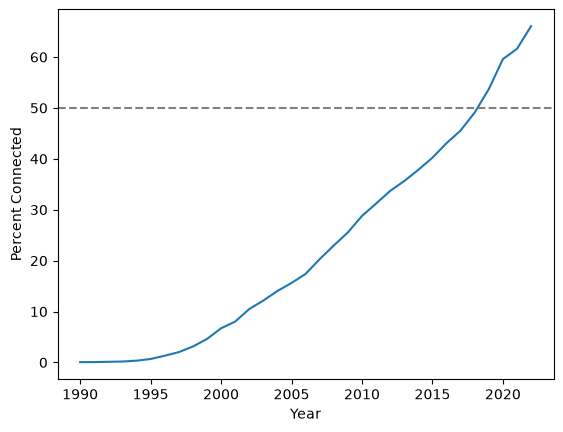

In [34]:
plt.plot(df['year'], df['percent'])
plt.axhline(50, color='gray', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Percent Connected')
plt.show()

The graph shows that over 50% of the world became connected to the internet by 2020.

### Finding the year we crossed 50%



In [8]:
over_half_connected = df.query('percent >= 50')
over_half_connected.head(1)

,year,internet_users,population,percent
29,2019,4194000000,7.811294e+09,53.69


The first year to surpass 50% was 2019.

While the Internet has grown exponentially, we still have work to do to ensure we are all connected as a global community.

## Project extensions

The file `extension-internet-users-by-continent.csv` provides data on the number of internet users across each continent, while the file `extension-historical-population-by-continent.csv` details historical population counts for each continent.


In [37]:
population_by_continent = pd.read_csv('extension-historical-population-by-continent.csv')
population_by_continent

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
...,...,...,...
1587,South America,2021,428331420
1588,South America,2022,430492814
1589,South America,2023,433024230


In [38]:
internet_users_by_continent = pd.read_csv('extension-internet-users-by-continent.csv')
internet_users_by_continent

,continent,year,internet_users
0,Africa,1990,0.000000e+00
1,Africa,1991,5.537650e+03
2,Africa,1992,1.649741e+04
...,...,...,...
189,South America,2019,2.815900e+08
190,South America,2020,3.102178e+08
191,South America,2021,3.177395e+08


## Merge Data

In [39]:

merged_df = internet_users_by_continent.merge(population_by_continent,on=['year','continent'],how='left')

In [40]:
merged_df

,continent,year,internet_users,population
0,Africa,1990,0.000000e+00,643775320
1,Africa,1991,5.537650e+03,661103806
2,Africa,1992,1.649741e+04,678558076
...,...,...,...,...
189,South America,2019,2.815900e+08,423548289
190,South America,2020,3.102178e+08,426213551
191,South America,2021,3.177395e+08,428331420


1990s in africa there was 0 internet users .

#### Let's explore wich continent reach the 50% of internet users over the total continent population

In [41]:
### First we will calculate percent of internet users for every year
merged_df['percent'] = merged_df.eval('internet_users / population').round(2)


In [42]:
merged_df

,continent,year,internet_users,population,percent
0,Africa,1990,0.000000e+00,643775320,0.00
1,Africa,1991,5.537650e+03,661103806,0.00
2,Africa,1992,1.649741e+04,678558076,0.00
...,...,...,...,...,...
189,South America,2019,2.815900e+08,423548289,0.66
190,South America,2020,3.102178e+08,426213551,0.73
191,South America,2021,3.177395e+08,428331420,0.74


In [43]:
merged_df.sort_values('year',ascending=True).query("percent >= 0.5").head(1)

,continent,year,internet_users,population,percent
112,North America,2006,259884750.0,519545237,0.5


- We see tht north america is the first continent that reached 50% of internet users of total population in 2006.

#### Let's check for the other continents

In [45]:
grouped = merged_df.sort_values('year',ascending=True).groupby('continent')

In [46]:
indexes = []
for _ , group in grouped:
    idx = group.query('percent >= 0.5').head(1).index.values
    if idx.shape[0] == 0 : continue
    indexes.append(idx[0])

merged_df.loc[indexes].sort_values('year')


,continent,year,internet_users,population,percent
112,North America,2006,2.598848e+08,519545237,0.50
145,Oceania,2007,1.802780e+07,35190038,0.51
82,Europe,2008,3.928105e+08,736640719,0.53
183,South America,2013,2.039407e+08,402022549,0.51
62,Asia,2020,2.603488e+09,4686811205,0.56


####  Based on output only 5 of 6 continent reached 50% of users, and Africa not in this list

we will analyse the users of internet for each continent and visualise them all

In [18]:
def draw_plot(x,y,y_ticks=None,legend_label='',x_label='',y_label='',color = 'c0'):
    plt.Figure(figsize=(3,2))
    ax = plt.gca()
    ax.plot(x,y,label = legend_label,color=color,alpha=0.4)
    ax.spines[['top','right','left']].set_visible(False)
    x_val = x[-1]
    y_val = y[-1]
    ax.text(x_val,y_val,f' {legend_label}',color=color)
    ax.set_xlabel(x_label)
    ax.set_ylim(0,1)
    ax.set_yticks([0,0.2,0.4,0.6,0.8],y_ticks)
    ax.tick_params('y',length=0)
    ax.grid(axis='y',alpha=0.4)
    plt.legend()

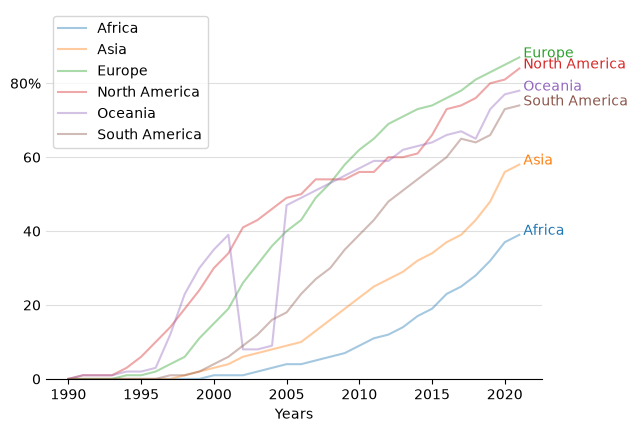

In [47]:
colors = ['C0','C1','C2','C3','C4','C5']
y_ticks = ['0','20','40','60','80%']
for (continent , group),color in zip(grouped,colors):
    draw_plot(group['year'].values,group['percent'].values,y_ticks,continent,'Years','Percent of Internet users',color)

In [55]:
grouped.get_group("Africa")

,continent,year,internet_users,population,percent
0,Africa,1990,0.000000e+00,643775320,0.00
1,Africa,1991,5.537650e+03,661103806,0.00
2,Africa,1992,1.649741e+04,678558076,0.00
...,...,...,...,...,...
29,Africa,2019,4.376317e+08,1348005687,0.32
30,Africa,2020,5.130481e+08,1380821355,0.37
31,Africa,2021,5.532078e+08,1413753270,0.39


The plot show an increase of users Internet after the 2000s, especially after 2007 after the launch of the first iphone by steve jobs followed by other's smartphone 

We also notice a decrease of internet users in oceania after the 2000s, in the same time where the Y2K bug or millennium bug show up and infected many company back then, and start to recover after 2005.

#### Let's see How much this percent of Internet users represent from the total population

In [48]:
def draw_barh(x,y,legend_label='',x_label='',y_label='',title='',colors='C0',height=0.8,text_x_margin = 0,text_y_margin = 0):
    ax = plt.gca()
    ax.barh(x,y,color=colors,label=legend_label,height=height)
    for idx,x_val in enumerate(y):
        color = ''
        if isinstance(colors,(list,tuple)):
            color = colors[idx]
        else :
            color = colors
        ax.text(x_val + text_x_margin,idx + text_y_margin,f' {x_val}',color=color)
    ax.spines[['top','right','bottom']].set_visible(False)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.tick_params('both',length=0)
    ax.grid(axis='x',alpha=0.4)
    plt.title(title)
    plt.legend()


##### Now Let's visualise our data

In [107]:
max_internet_users = merged_df.loc[grouped['percent'].idxmax()]

sorted_percent = max_internet_users.sort_values("percent",ascending=True)
sorted_population =  max_internet_users.sort_values("population",ascending=True)

max_internet_users

,continent,year,internet_users,population,percent
31,Africa,2021,5.532078e+08,1413753270,0.39
63,Asia,2021,2.753528e+09,4716999175,0.58
95,Europe,2021,6.549271e+08,749931027,0.87
127,North America,2021,5.025411e+08,600876352,0.84
159,Oceania,2021,3.474478e+07,44558538,0.78
191,South America,2021,3.177395e+08,428331420,0.74


In [92]:
sorted_percent

,continent,year,internet_users,population,percent
31,Africa,2021,5.532078e+08,1413753270,0.39
63,Asia,2021,2.753528e+09,4716999175,0.58
191,South America,2021,3.177395e+08,428331420,0.74
159,Oceania,2021,3.474478e+07,44558538,0.78
127,North America,2021,5.025411e+08,600876352,0.84
95,Europe,2021,6.549271e+08,749931027,0.87


(0.0, 1.0)

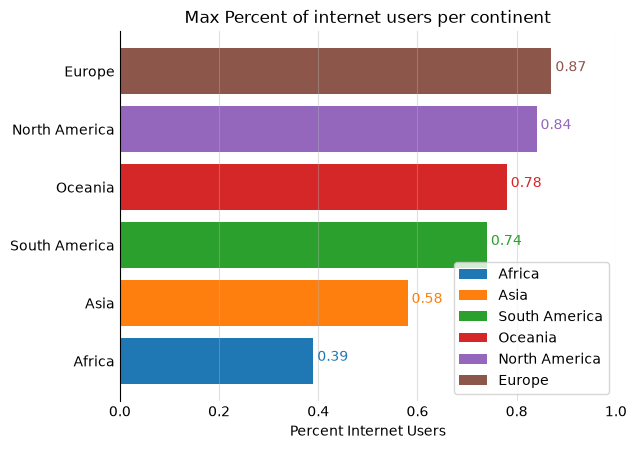

In [108]:
draw_barh(sorted_percent["continent"],sorted_percent['percent'],sorted_percent['continent'],'Percent Internet Users','',"Max Percent of internet users per continent",colors)
plt.xlim(0,1)

In [109]:
sorted_population["per_billion"] = sorted_population.eval("population / 1000e6").round(2)
sorted_population

,continent,year,internet_users,population,percent,per_billion
159,Oceania,2021,3.474478e+07,44558538,0.78,0.04
191,South America,2021,3.177395e+08,428331420,0.74,0.43
127,North America,2021,5.025411e+08,600876352,0.84,0.60
95,Europe,2021,6.549271e+08,749931027,0.87,0.75
31,Africa,2021,5.532078e+08,1413753270,0.39,1.41
63,Asia,2021,2.753528e+09,4716999175,0.58,4.72


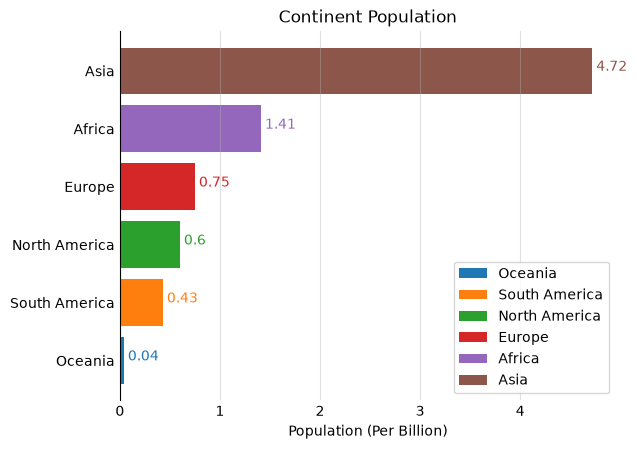

In [110]:
draw_barh(sorted_population["continent"],sorted_population['per_billion'],sorted_population['continent'],'Population (Per Billion)','',"Continent Population",colors)


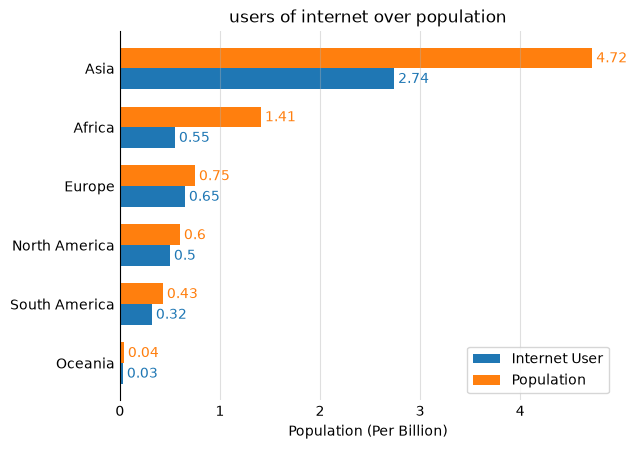

In [111]:

x = np.arange(sorted_population.shape[0])
users_internet = sorted_population['percent'] * sorted_population['per_billion']
bar_height = 0.35


draw_barh(x - bar_height / 2,users_internet.round(2),'Internet User','Per Million','','users over population','C0',bar_height,text_y_margin=-0.25  )
draw_barh(x + bar_height / 2,sorted_population['per_billion'],'Population','Population (Per Billion)','','users of internet over population','C1',bar_height,text_y_margin=0.1)
void = plt.yticks(x,sorted_population['continent'])

Text(0.5, 0, 'Population (per Billion)')

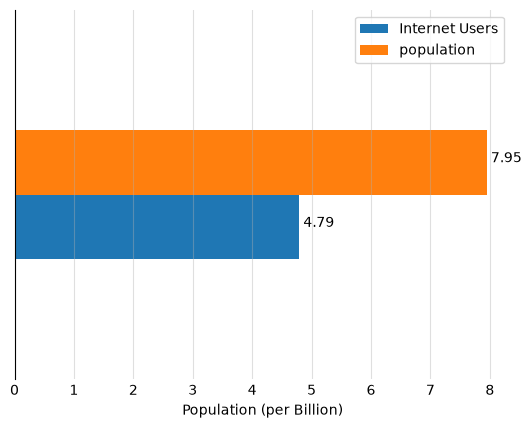

In [157]:
#let's see How much this percent actually represent from the total world population
year = 2021
height = 0.35
x1 = 1 - height / 2
x2 = 1 + height / 2
y1 = users_internet.sum()
y2 = sorted_population["per_billion"].sum()

ax = plt.gca()
ax.barh(x1,y1,height=height,label="Internet Users")
ax.barh(x2,y2,height=height,label="population")
ax.text(y1,x1,f' {y1.round(2)}')
ax.text(y2,x2,f' {y2.round(2)}')
ax.grid(axis='x',alpha=0.4)
ax.legend()
ax.spines[['right','top','bottom']].set_visible(False)
ax.tick_params(axis='both',length = 0)
plt.ylim(0,2)
plt.yticks([0,1,2],['',"",''])

plt.xlabel("Population (per Billion)")


Based on the three Graph ,we see that we're too clos to fully connected . even if africa still not half connected but we are on our way .